In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import RFE, SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_fscore_support
import pickle
from sklearn.neighbors import KNeighborsClassifier

Task 1

In [134]:
#Loading the dataset
file_path = r"C:\\Users\\david.sheridan\\Downloads\\insurance.csv"
df = pd.read_csv(file_path)
df.head()

,age,gender,bmi,children,smoker,region,insurance_cost
0,18,male,33.770,1,no,southeast,1725.55230
1,18,male,34.100,0,no,southeast,1137.01100
2,18,female,26.315,0,no,northeast,2198.18985
3,18,female,38.665,2,no,northeast,3393.35635
4,18,female,35.625,0,no,northeast,2211.13075


In [136]:
#Step 1: Binarising the target column `charges`
median_cost = df['insurance_cost'].median()
df['insurance_cost_binary'] = (df['insurance_cost'] > median_cost).astype(int)

In [138]:
#droping the original insurance cost column
df.drop('insurance_cost', axis=1, inplace=True)

In [140]:
#Separating features and target
X = df.drop(columns=['insurance_cost_binary'])
y = df['insurance_cost_binary']

In [142]:
#Identifying categorical and numerical columns
categorical_cols = ['gender', 'smoker', 'region']
numerical_cols = ['age', 'bmi', 'children']

In [144]:
#Preprocessing for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first'))
])

In [146]:
#Combining preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

In [148]:
#Dimensionality reduction techniques
#1. PCA
pca = PCA(n_components=5)

#2. RFE
rfe_selector = RFE(estimator=RandomForestClassifier(n_estimators=10), n_features_to_select=5)

#3. SelectKBest
select_k_best = SelectKBest(score_func=f_classif, k=5)

In [150]:
#Defining classifiers
svm_clf = SVC(probability=True)
rf_clf = RandomForestClassifier()
knn_clf = KNeighborsClassifier()

In [152]:
#Creating pipelines
pipe_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('dim_red', pca),
    ('classifier', svm_clf)
])

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('dim_red', rfe_selector),
    ('classifier', rf_clf)
])

pipe_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('dim_red', select_k_best),
    ('classifier', knn_clf)
])

In [154]:
#Hyperparameter tuning
param_grid_svm = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['linear', 'rbf']
}

param_grid_rf = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [3, 5, 7]
}

param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7]
}

In [156]:
#Splitting data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [158]:
# Grid search
grid_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=5)
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5)
grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=5)

# Fit models
grid_svm.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)
grid_knn.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'bmi',
                                                                          'children']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(drop='first'))]),
                                                                         ['gender',
                                                                          'smoker',
                                                                          'region'])])),
                                       ('dim_red', SelectKBest(k=5)),
                                       ('classifier', KNeighborsClassifier())]),
             param_grid={'classifier__n_neighbors': [3, 5, 7]})

In [159]:
# Evaluation function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    return acc, prec, rec, f1, fpr, tpr, roc_auc

In [160]:
# Evaluate each model
results = {}
for name, model in [('SVM', grid_svm), ('Random Forest', grid_rf), ('k-NN', grid_knn)]:
    acc, prec, rec, f1, fpr, tpr, roc_auc = evaluate_model(model, X_test, y_test)
    results[name] = {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}

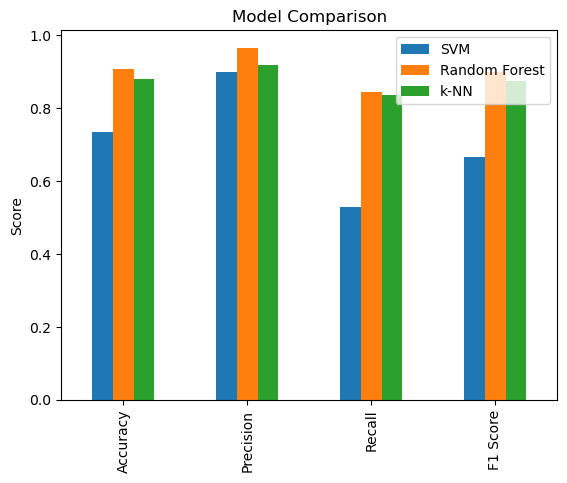

In [161]:
# Compare models
metrics_df = pd.DataFrame({k: [v['acc'], v['prec'], v['rec'], v['f1']] for k, v in results.items()},
                          index=['Accuracy', 'Precision', 'Recall', 'F1 Score'])
metrics_df.plot.bar()
plt.title("Model Comparison")
plt.ylabel("Score")
plt.show()

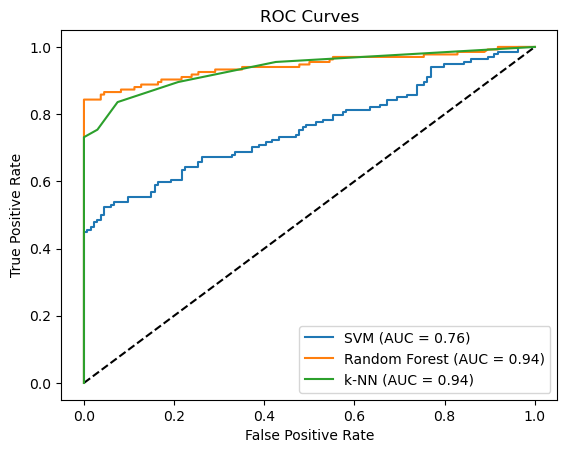

In [166]:
# Plot ROC curves
plt.figure()
plt.plot([0, 1], [0, 1], 'k--')
for name in results:
    plt.plot(results[name]['fpr'], results[name]['tpr'], label=f'{name} (AUC = {results[name]["auc"]:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.show()

In this task, I transformed the insurance_cost into a binary classification target based on the median. I created and trained three pipelines with SVM (with PCA), Random Forest (with RFE), and k-Nearest Neighbors (with SelectKBest). Each pipeline included data preprocessing and dimensionality reduction. I applied grid search for hyperparameter tuning and compared the models using accuracy, precision, recall, F1-score, and AUC. The ROC curves provided a visual comparison. Among the three, Random Forest performed the best based on the evaluation metrics.